## Load beta tsv

In [2]:
import pandas as pd
import os


# Load the TSV file
file_path = '/home/gagpat01/Documents/GutBrain/BIDS_results/3dLmer/results/mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_qc_final/beta_estimates_sess1_x_twl24_clustered_ses-1_20260127_151001.tsv'
df_beta = pd.read_csv(file_path, sep='\t')

# Display first few rows
df_beta.head()


,participant_id,session,run,contrast,cluster_id,cluster_size,com_mni_x,com_mni_y,com_mni_z,mean_beta,std_beta,min_beta,max_beta
0,sub-RCX097,ses-1,run-1,sub-RCX097_ses-1_run-1_effect-size_v7_literatu...,1,177,-30.3051,-57.0,28.1525,-0.154341,0.104107,-0.377912,0.082859
1,sub-RCX097,ses-1,run-1,sub-RCX097_ses-1_run-1_effect-size_v7_literatu...,2,35,14.1429,-52.2,30.7714,0.103511,0.096375,-0.055761,0.317428
2,sub-RCX097,ses-1,run-2,sub-RCX097_ses-1_run-2_effect-size_v7_literatu...,1,177,-30.3051,-57.0,28.1525,-0.126146,0.091211,-0.342492,0.186022
3,sub-RCX097,ses-1,run-2,sub-RCX097_ses-1_run-2_effect-size_v7_literatu...,2,35,14.1429,-52.2,30.7714,-0.002307,0.068128,-0.209866,0.086993
4,sub-RCX097,ses-1,run-3,sub-RCX097_ses-1_run-3_effect-size_v7_literatu...,1,177,-30.3051,-57.0,28.1525,-0.196528,0.218243,-0.722966,0.374712


In [3]:
# Check the data type of session column
print(df_beta['session'].dtype)
print(df_beta['session'].unique())

# Rename session column - handle both string and already converted formats
if df_beta['session'].dtype == 'object':
    df_beta['session'] = df_beta['session'].str.replace('ses-', '').astype(int)
else:
    # If already numeric, ensure it's int
    df_beta['session'] = df_beta['session'].astype(int)

# Remove rows where participant_id contains 'RGC'
df_beta = df_beta[~df_beta['participant_id'].str.contains('RGC', na=False)]

# Aggregate by participant_id and cluster_id (averaging across runs and sessions)
df_aggregated_beta = df_beta.groupby(['participant_id', 'cluster_id']).agg({
    'cluster_size': 'first',  # assuming cluster_size is constant per cluster
    'com_mni_x': 'first',
    'com_mni_y': 'first',
    'com_mni_z': 'first',
    'mean_beta': 'mean',  # average across runs and sessions
    'std_beta': 'mean',   # average std across runs and sessions
    'min_beta': 'min',    # minimum across runs and sessions
    'max_beta': 'max'     # maximum across runs and sessions
}).reset_index()

# Display first few rows
df_aggregated_beta

object
['ses-1']


,participant_id,cluster_id,cluster_size,com_mni_x,com_mni_y,com_mni_z,mean_beta,std_beta,min_beta,max_beta
0,sub-RCX097,1,177,-30.3051,-57.0,28.1525,-0.159005,0.137854,-0.722966,0.374712
1,sub-RCX097,2,35,14.1429,-52.2,30.7714,0.045290,0.086197,-0.209866,0.317428
2,sub-RCX126,1,177,-30.3051,-57.0,28.1525,0.470665,0.165268,-0.026089,1.083901
3,sub-RCX126,2,35,14.1429,-52.2,30.7714,0.261061,0.121652,-0.218902,0.757080
4,sub-RCX136,1,177,-30.3051,-57.0,28.1525,0.089314,0.122450,-0.368184,0.345597
...,...,...,...,...,...,...,...,...,...,...
145,sub-RND073,2,35,14.1429,-52.2,30.7714,0.085165,0.057658,-0.123486,0.231391
146,sub-RND074,1,177,-30.3051,-57.0,28.1525,-0.059730,0.079794,-0.272863,0.216493
147,sub-RND074,2,35,14.1429,-52.2,30.7714,0.056351,0.072688,-0.157524,0.391567
148,sub-RND076,1,177,-30.3051,-57.0,28.1525,0.059635,0.103676,-0.291807,0.410717


In [4]:
# Load the 3dLmer data table
lmer_table_path = '/home/gagpat01/Documents/GutBrain/BIDS_results/3dLmer/3dlmerdata_table_with_covariates_mod_hi_vs_mod_lo_v7_literature_complex_psc_twl_24_qc_final.txt'
df_lmer = pd.read_csv(lmer_table_path, sep='\t')

# Display first few rows
df_lmer.head()

,Subj,sess,run,sex,type_chx,handedness,vas_debut,age_baseline,bmi_baseline,twl_rech_24,InputFile
0,rcx097,1,1,female,3,right,0.073987,-4.134714,0.107199,0.358097,/home/pagag24/projects/def-amichaud/share/GutB...
1,rcx097,1,2,female,3,right,0.073987,-4.134714,0.107199,0.358097,/home/pagag24/projects/def-amichaud/share/GutB...
2,rcx097,2,1,female,3,right,-3.162124,-4.134714,0.107199,0.358097,/home/pagag24/projects/def-amichaud/share/GutB...
3,rcx097,2,2,female,3,right,-3.162124,-4.134714,0.107199,0.358097,/home/pagag24/projects/def-amichaud/share/GutB...
4,rcx097,2,3,female,3,right,-3.162124,-4.134714,0.107199,0.358097,/home/pagag24/projects/def-amichaud/share/GutB...


In [5]:
import re

# Function to convert 'sub-RCX096' → 'rcx096', 'sub-RND001' → 'rnd001'
def from_afni_id(x):
    m = re.match(r"sub-([A-Z]+)(\d+)", x)
    if m:
        prefix = m.group(1).lower()
        number = m.group(2).zfill(3)
        return f"{prefix}{number}"
    return x

# Convert participant_id in df_aggregated_beta to match df_lmer format
df_aggregated_beta['Subj'] = df_aggregated_beta['participant_id'].apply(from_afni_id)

# Drop the old participant_id column and rename cluster_id to match if needed
df_aggregated_beta = df_aggregated_beta.drop(columns=['participant_id'])

# Reorder columns to put Subj first
cols = ['Subj'] + [col for col in df_aggregated_beta.columns if col != 'Subj']
df_aggregated_beta = df_aggregated_beta[cols]

# Display result
print("Reformed df_aggregated_beta:")
print(df_aggregated_beta.head())

print("\ndf_lmer Subj values (first 10):")
print(df_lmer['Subj'].unique()[:10])

print("\ndf_aggregated_beta Subj values (first 10):")
print(df_aggregated_beta['Subj'].unique()[:10])

Reformed df_aggregated_beta:
     Subj  cluster_id  cluster_size  com_mni_x  com_mni_y  com_mni_z  \
0  rcx097           1           177   -30.3051      -57.0    28.1525   
1  rcx097           2            35    14.1429      -52.2    30.7714   
2  rcx126           1           177   -30.3051      -57.0    28.1525   
3  rcx126           2            35    14.1429      -52.2    30.7714   
4  rcx136           1           177   -30.3051      -57.0    28.1525   

   mean_beta  std_beta  min_beta  max_beta  
0  -0.159005  0.137854 -0.722966  0.374712  
1   0.045290  0.086197 -0.209866  0.317428  
2   0.470665  0.165268 -0.026089  1.083901  
3   0.261061  0.121652 -0.218902  0.757080  
4   0.089314  0.122450 -0.368184  0.345597  

df_lmer Subj values (first 10):
['rcx097' 'rcx126' 'rcx136' 'rcx146' 'rcx148' 'rcx164' 'rcx200' 'rcx211'
 'rcx219' 'rcx247']

df_aggregated_beta Subj values (first 10):
['rcx097' 'rcx126' 'rcx136' 'rcx146' 'rcx147' 'rcx148' 'rcx164' 'rcx191'
 'rcx200' 'rcx203']


In [6]:
# Filter df_lmer to only keep session 1
df_lmer_sess1 = df_lmer[df_lmer['sess'] == 1].copy()

print(f"df_lmer rows before filtering: {len(df_lmer)}")
print(f"df_lmer rows after filtering (sess=1): {len(df_lmer_sess1)}")

# Aggregate by Subj (averaging across runs)
df_lmer_sess1_agg = df_lmer_sess1.groupby('Subj').agg({
    'sex': 'first',
    'type_chx': 'first',
    'handedness': 'first',
    'vas_debut': 'mean',
    'age_baseline': 'first',
    'bmi_baseline': 'first',
    'twl_rech_24': 'first'
}).reset_index()

# Drop the sess and run columns (already aggregated)
print(f"\ndf_lmer_sess1_agg rows: {len(df_lmer_sess1_agg)}")
print(f"Unique subjects in df_lmer_sess1_agg: {df_lmer_sess1_agg['Subj'].nunique()}")

# Get unique subjects for merging
print(f"Unique subjects in df_aggregated_beta: {df_aggregated_beta['Subj'].nunique()}")

# Merge the two dataframes on Subj
df_merged = pd.merge(
    df_aggregated_beta,
    df_lmer_sess1_agg,
    on='Subj',
    how='inner'  # Use 'inner' to keep only subjects present in both dataframes
)

print(f"\nMerged dataframe rows: {len(df_merged)}")
print(f"Unique subjects in merged df: {df_merged['Subj'].nunique()}")

# Display first few rows
print("\nFirst rows of merged dataframe:")
df_merged.head(50)

df_lmer rows before filtering: 471
df_lmer rows after filtering (sess=1): 131

df_lmer_sess1_agg rows: 51
Unique subjects in df_lmer_sess1_agg: 51
Unique subjects in df_aggregated_beta: 75

Merged dataframe rows: 102
Unique subjects in merged df: 51

First rows of merged dataframe:


,Subj,cluster_id,cluster_size,com_mni_x,com_mni_y,com_mni_z,mean_beta,std_beta,min_beta,max_beta,sex,type_chx,handedness,vas_debut,age_baseline,bmi_baseline,twl_rech_24
0,rcx097,1,177,-30.3051,-57.0,28.1525,-0.159005,0.137854,-0.722966,0.374712,female,3,right,0.073987,-4.134714,0.107199,0.358097
1,rcx097,2,35,14.1429,-52.2,30.7714,0.045290,0.086197,-0.209866,0.317428,female,3,right,0.073987,-4.134714,0.107199,0.358097
2,rcx126,1,177,-30.3051,-57.0,28.1525,0.470665,0.165268,-0.026089,1.083901,female,1,right,-0.762124,13.865286,3.844177,0.232094
3,rcx126,2,35,14.1429,-52.2,30.7714,0.261061,0.121652,-0.218902,0.757080,female,1,right,-0.762124,13.865286,3.844177,0.232094
4,rcx136,1,177,-30.3051,-57.0,28.1525,0.089314,0.122450,-0.368184,0.345597,male,1,right,3.837876,7.865286,3.398413,0.308729
5,rcx136,2,35,14.1429,-52.2,30.7714,0.020781,0.066136,-0.143012,0.176593,male,1,right,3.837876,7.865286,3.398413,0.308729
6,rcx146,1,177,-30.3051,-57.0,28.1525,-0.021463,0.071548,-0.378605,0.259890,female,2,right,-1.162124,-0.534714,-2.799210,0.363415
7,rcx146,2,35,14.1429,-52.2,30.7714,-0.029647,0.054249,-0.215318,0.157166,female,2,right,-1.162124,-0.534714,-2.799210,0.363415
8,rcx148,1,177,-30.3051,-57.0,28.1525,0.005877,0.129050,-0.263253,0.717784,male,1,right,-1.662124,14.965286,-0.693937,0.416667
9,rcx148,2,35,14.1429,-52.2,30.7714,-0.060960,0.098242,-0.294348,0.132425,male,1,right,-1.662124,14.965286,-0.693937,0.416667


/home/gagpat01/fmriprep_env/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/home/gagpat01/fmriprep_env/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


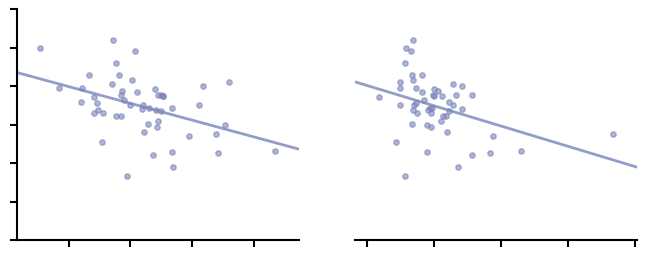


Cluster beta plots completed!


In [18]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter, MaxNLocator
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Create figure with 2 subplots (1 row, 2 columns) with increased spacing
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Define colors for each cluster - same color for both
colors = ['#7985ba', '#7985ba']  # Blue-purple for both

# Get unique clusters
clusters = sorted(df_merged['cluster_id'].unique())

# Y-axis limits - fixed from 0 to 60
y_limits = (0, 60)

# Loop through each cluster
for idx, cluster_id in enumerate(clusters):
    ax = axes[idx]
    
    # Filter data for current cluster
    cluster_data = df_merged[df_merged['cluster_id'] == cluster_id].copy()
    
    # Get clean data (remove NaN)
    plot_data = cluster_data[['mean_beta', 'twl_rech_24', 'Subj']].dropna()
    
    if len(plot_data) > 0:
        # Scale twl_rech_24 by 100
        plot_data['twl_rech_24_scaled'] = plot_data['twl_rech_24'] * 100
        
        # Determine x-axis limits for this specific cluster
        x_min, x_max = plot_data['mean_beta'].min(), plot_data['mean_beta'].max()
        x_range = x_max - x_min
        x_limits = (x_min - 0.1 * x_range, x_max + 0.1 * x_range)
        
        # Fit mixed model to get beta coefficient and confidence interval
        formula = 'twl_rech_24_scaled ~ mean_beta'
        mixed_model = smf.mixedlm(formula, plot_data, groups=plot_data['Subj'], re_formula='1')
        mixed_model_fit = mixed_model.fit()
        
        # Get beta coefficient and p-value
        beta_mean_beta = mixed_model_fit.params['mean_beta']
        beta_intercept = mixed_model_fit.params['Intercept']
        p_value = mixed_model_fit.pvalues['mean_beta']
        
        # Scatter plot with smaller points
        ax.scatter(plot_data['mean_beta'], plot_data['twl_rech_24_scaled'],
                  alpha=0.6, s=15, color=colors[idx])
        
        # Add regression line based on model
        x_line = np.linspace(x_limits[0], x_limits[1], 100)
        y_line = beta_intercept + beta_mean_beta * x_line
        
        ax.plot(x_line, y_line, color=colors[idx], alpha=0.8, linewidth=2)
        
        # Set x-limits - SPECIFIC to this cluster
        ax.set_xlim(x_limits)
        
        # Set x-axis to have exactly 5 ticks
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    
    # Remove tick labels for both x and y axes
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    
    # Keep tick marks but remove labels
    if idx == 0:
        # Add tick marks on left side without labels
        ax.tick_params(axis='y', which='major', left=True, labelleft=False, 
                      length=5, width=1.5, color='black')
        ax.spines['left'].set_linewidth(1.5)
        ax.spines['left'].set_color('black')
        ax.spines['left'].set_visible(True)
    else:
        # Remove y-axis completely for second subplot
        ax.spines['left'].set_visible(False)
        ax.tick_params(axis='y', which='both', left=False, labelleft=False)
    
    # Remove x-label and y-label
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    # Set y-limits
    ax.set_ylim(y_limits)
    
    # Add tick marks on x-axis (bottom) without labels
    ax.tick_params(axis='x', which='major', bottom=True, labelbottom=False, 
                  length=5, width=1.5, color='black')
    
    # Set spine (axis line) width and color
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['bottom'].set_color('black')
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Remove grid
    ax.grid(False)

# Increase spacing between subplots - call AFTER tight_layout or instead of it
plt.subplots_adjust(wspace=0.2)  # Increase horizontal spacing

plt.show()

print("\nCluster beta plots completed!")